In [33]:
# Imports

from Consumer import ConsumerClass
import numpy as np
import matplotlib.pyplot as plt
import time

# Model Project

### 1 A consumer with two nets

In [34]:
## 1.1 The problem in nested budget shares 


## 1.2 Calibration
# Complements
model_complements = ConsumerClass()

# Substitutes
model_substitutes = ConsumerClass(
    par={"sigma_B": 3.0}
)

#Check that the models are correctly specified
print("model_complements")
print(model_complements)
print()
print("model_substitutes")
print(model_substitutes)



model_complements
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000

model_substitutes
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


### 2 Solving the model numercally

Calibration 1: Complements (sigma_B = 0.40)
Grid search with N=100
  s1 = 0.535354, w = 0.444444
  s1 = 0.535354, s2 = 0.206510, s3 = 0.258137
  utility = 3.401482
  function evaluations = 10000

Calibration 2: Substitutes (sigma_B = 3.00)
Grid search with N=100
  s1 = 0.535354, w = 0.696970
  s1 = 0.535354, s2 = 0.323845, s3 = 0.140802
  utility = 3.485005
  function evaluations = 10000


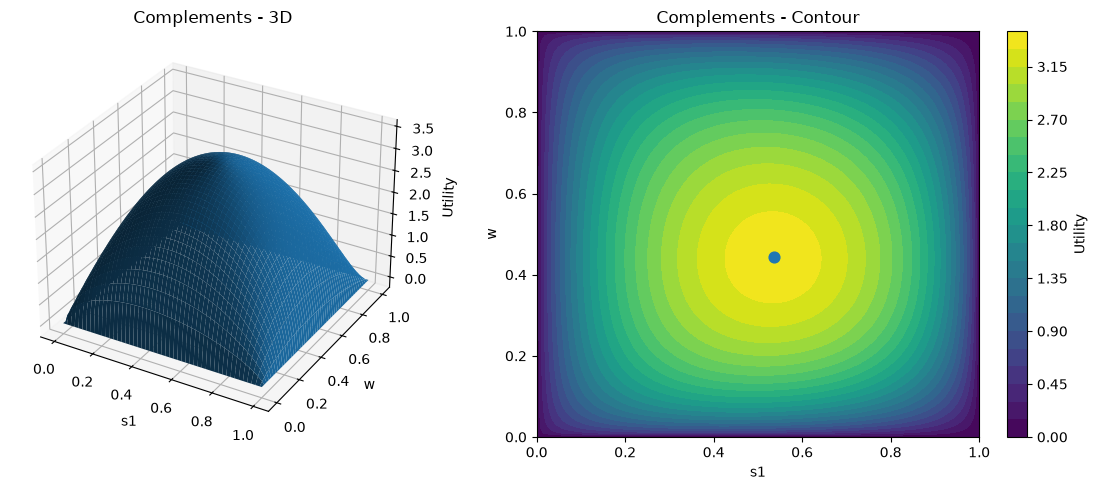

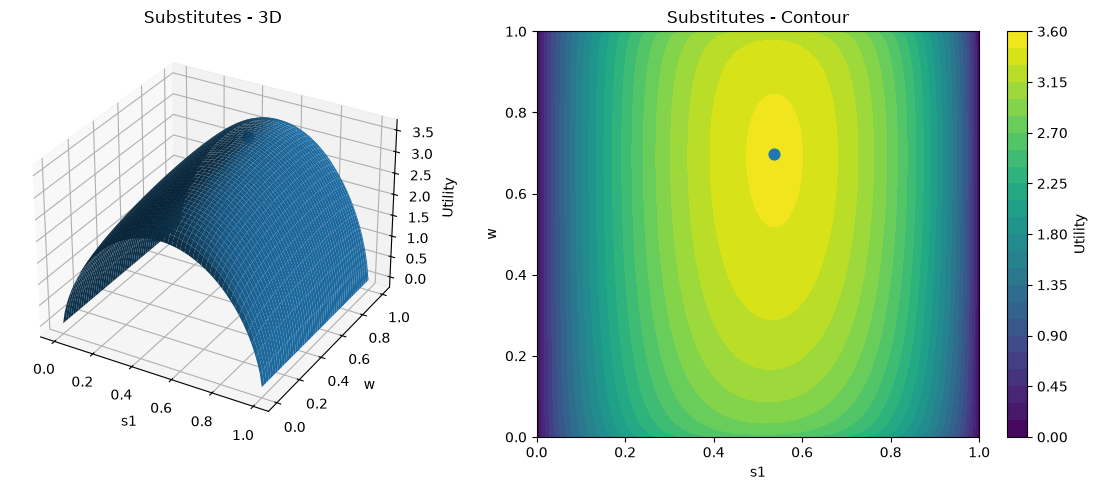

Complements
N =   50: s1 = 0.530612, w = 0.448980, u = 3.400748, evaluations = 2500
N =  100: s1 = 0.535354, w = 0.444444, u = 3.401482, evaluations = 10000
N =  500: s1 = 0.535070, w = 0.438878, u = 3.401674, evaluations = 250000
N = 1000: s1 = 0.535536, w = 0.439439, u = 3.401680, evaluations = 1000000

Substitutes
N =   50: s1 = 0.530612, w = 0.693878, u = 3.484594, evaluations = 2500
N =  100: s1 = 0.535354, w = 0.696970, u = 3.485005, evaluations = 10000
N =  500: s1 = 0.539078, w = 0.691383, u = 3.485097, evaluations = 250000
N = 1000: s1 = 0.538539, w = 0.692693, u = 3.485104, evaluations = 1000000

Complements

Grid search:
s1 = 0.535536
w  = 0.439439
u  = 3.401680
evaluations = 1000000
time = 0.043283 seconds

L-BFGS-B:
s1 = 0.535623
w  = 0.439479
u  = 3.401680
evaluations = 18
time = 0.001468 seconds

Substitutes

Grid search:
s1 = 0.538539
w  = 0.692693
u  = 3.485104
evaluations = 1000000
time = 0.049488 seconds

L-BFGS-B:
s1 = 0.538225
w  = 0.692308
u  = 3.485105
evaluation

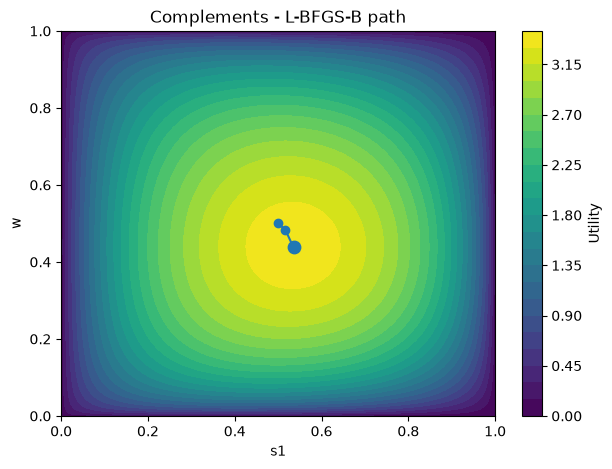

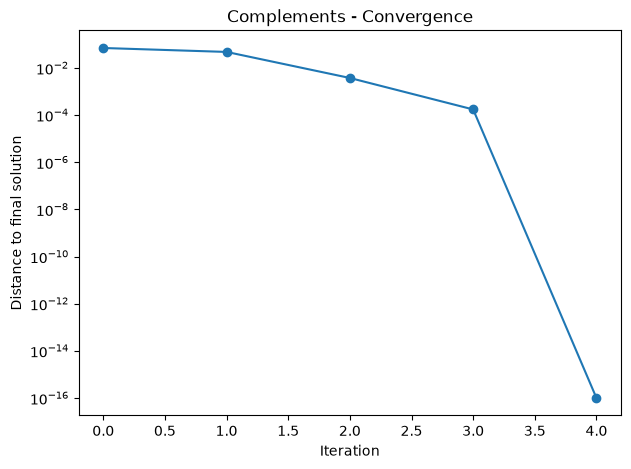

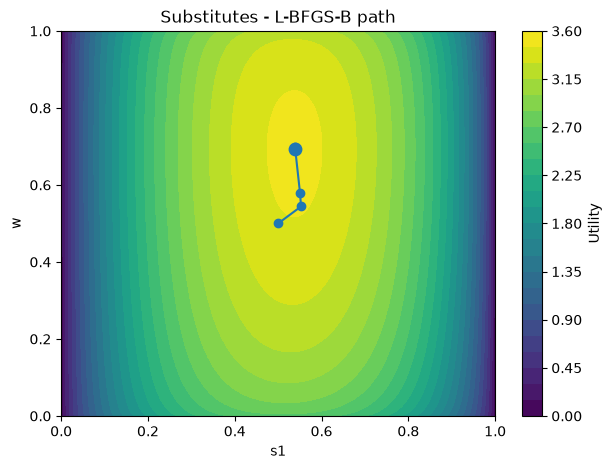

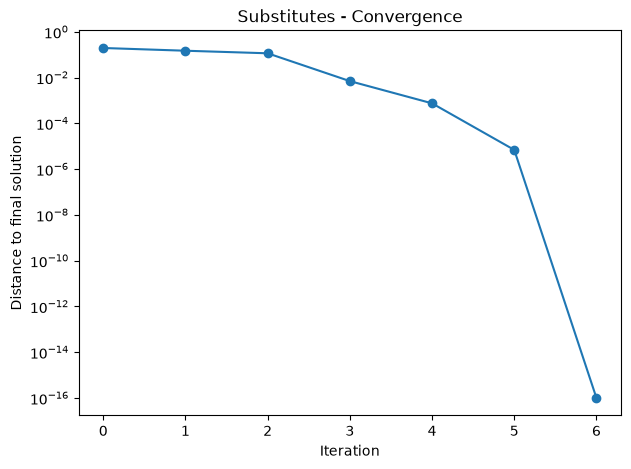

In [38]:
## 2.1 A two-dimensional grid search


# 2.1.1 Make a grid of N values of w (use solve_grid)
# Calibration 1: Complements
print("Calibration 1: Complements (sigma_B = 0.40)")
sol_comp = model_complements.solve_grid(N=100)

print()

# Calibration 2: Substitutes
print("Calibration 2: Substitutes (sigma_B = 3.00)")
sol_sub = model_substitutes.solve_grid(N=100)


# 2.1.2 Plot utility over the nested shares
def plot_grid_solution(sol, title):

    fig = plt.figure(figsize=(12, 5))

    # 3D plot
    ax = fig.add_subplot(1, 2, 1, projection='3d')

    ax.plot_surface(
        sol.s1_grid,
        sol.w_grid,
        sol.u_grid
    )

    ax.scatter(
        sol.s1,
        sol.w,
        sol.u,
        s=60
    )

    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    ax.set_zlabel('Utility')
    ax.set_title(f'{title} - 3D')

    # Contour plot
    ax = fig.add_subplot(1, 2, 2)

    contour = ax.contourf(
        sol.s1_grid,
        sol.w_grid,
        sol.u_grid,
        levels=30
    )

    ax.scatter(
        sol.s1,
        sol.w,
        s=60
    )

    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    ax.set_title(f'{title} - Contour')

    fig.colorbar(contour, ax=ax, label='Utility')

    plt.tight_layout()
    plt.show()


plot_grid_solution(
    sol_comp,
    'Complements'
)

plot_grid_solution(
    sol_sub,
    'Substitutes'
)


# 2.1.3 Trying N = 50, 500 and 1000
N_values = [50, 100, 500, 1000]

print("Complements")

for N in N_values:
    sol = model_complements.solve_grid(N=N, do_print=False)

    print(
        f"N = {N:4d}: "
        f"s1 = {sol.s1:.6f}, "
        f"w = {sol.w:.6f}, "
        f"u = {sol.u:.6f}, "
        f"evaluations = {sol.nfev}"
    )


print()
print("Substitutes")

for N in N_values:
    sol = model_substitutes.solve_grid(N=N, do_print=False)

    print(
        f"N = {N:4d}: "
        f"s1 = {sol.s1:.6f}, "
        f"w = {sol.w:.6f}, "
        f"u = {sol.u:.6f}, "
        f"evaluations = {sol.nfev}"
    )


# 2.1.4 Comparing the two calibrations

## 2.2 L-BFGS-B

# 2.2.1 Solving the problem

print()
# Complements

# Grid search
start = time.perf_counter()
grid_comp = model_complements.solve_grid(N=1000, do_print=False)
time_grid_comp = time.perf_counter() - start

# L-BFGS-B
start = time.perf_counter()
lbfgs_comp = model_complements.solve(do_print=False)
time_lbfgs_comp = time.perf_counter() - start

print("Complements")
print()
print("Grid search:")
print(f"s1 = {grid_comp.s1:.6f}")
print(f"w  = {grid_comp.w:.6f}")
print(f"u  = {grid_comp.u:.6f}")
print(f"evaluations = {grid_comp.nfev}")
print(f"time = {time_grid_comp:.6f} seconds")

print()

print("L-BFGS-B:")
print(f"s1 = {lbfgs_comp.s1:.6f}")
print(f"w  = {lbfgs_comp.w:.6f}")
print(f"u  = {lbfgs_comp.u:.6f}")
print(f"evaluations = {lbfgs_comp.res.nfev}")
print(f"time = {time_lbfgs_comp:.6f} seconds")

print()
# Substitutes

# Grid search
start = time.perf_counter()
grid_sub = model_substitutes.solve_grid(N=1000, do_print=False)
time_grid_sub = time.perf_counter() - start

# L-BFGS-B
start = time.perf_counter()
lbfgs_sub = model_substitutes.solve(do_print=False)
time_lbfgs_sub = time.perf_counter() - start

print("Substitutes")
print()
print("Grid search:")
print(f"s1 = {grid_sub.s1:.6f}")
print(f"w  = {grid_sub.w:.6f}")
print(f"u  = {grid_sub.u:.6f}")
print(f"evaluations = {grid_sub.nfev}")
print(f"time = {time_grid_sub:.6f} seconds")

print()

print("L-BFGS-B:")
print(f"s1 = {lbfgs_sub.s1:.6f}")
print(f"w  = {lbfgs_sub.w:.6f}")
print(f"u  = {lbfgs_sub.u:.6f}")
print(f"evaluations = {lbfgs_sub.res.nfev}")
print(f"time = {time_lbfgs_sub:.6f} seconds")


# 2.2.2 Record the convergence pathwith the callback argument of optimize.minimize
lbfgs_comp = model_complements.solve(do_print=False)
lbfgs_sub = model_substitutes.solve(do_print=False)


def plot_convergence(grid_sol, lbfgs_sol, title):

    # Contour plot with optimization path
    fig, ax = plt.subplots(figsize=(7, 5))

    contour = ax.contourf(
        grid_sol.s1_grid,
        grid_sol.w_grid,
        grid_sol.u_grid,
        levels=30
    )

    path = lbfgs_sol.path

    ax.plot(
        path[:, 0],
        path[:, 1],
        marker='o'
    )

    ax.scatter(
        lbfgs_sol.s1,
        lbfgs_sol.w,
        s=80
    )

    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    ax.set_title(f'{title} - L-BFGS-B path')

    fig.colorbar(contour, ax=ax, label='Utility')

    plt.show()

    # Distance to final solution
    final_point = np.array([
        lbfgs_sol.s1,
        lbfgs_sol.w
    ])

    distances = np.linalg.norm(
        path - final_point,
        axis=1
    )

    # Avoid log(0)
    distances = np.maximum(distances, 1e-16)

    plt.figure(figsize=(7, 5))

    plt.semilogy(
        range(len(distances)),
        distances,
        marker='o'
    )

    plt.xlabel('Iteration')
    plt.ylabel('Distance to final solution')
    plt.title(f'{title} - Convergence')

    plt.show()

    # Complements
plot_convergence(
    grid_comp,
    lbfgs_comp,
    'Complements'
)

# Substitutes
plot_convergence(
    grid_sub,
    lbfgs_sub,
    'Substitutes'
)


# 2.2.3 Solve from six different starting points

# 2.2.4 Report the two shares


### 3 Relative prices and demand

In [36]:
# 3.1 Solve the model

# 3.2 Which calibration has higher p3 raise

# 3.3 Number od bus trips when train tickets get more expensive

# 3.4 How train tickets change

### 4 Lump-sum taxes and product taxes

In [37]:
# 4.1 Implement tax_revenue() (eq. 5).

# 4.2 Consider five product taxes:

# 4.3 Which of the curves have a top, and which just keep rising?

# 4.4 Plot of the consumer’s utility against the revenue raised

# 4.5 Let the government need R = 0.20, i.e. 2 percent of income

### 5 Extension